In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
import cmocean

In [4]:
from scipy import stats

In [5]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 2.0
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [6]:
def plot_decorator():
    plt.minorticks_on()
    plt.tick_params(which='minor', axis='x', bottom=False)
    plt.grid(alpha=0.1)

In [7]:
import matplotlib as m

In [8]:
import matplotlib.patches as mpatches

In [9]:
# plt.style.use('dark_background')

### Functions needed for the analysis

In [10]:
# import matplotlib as m
# from matplotlib.colors import BoundaryNorm as BM
# import matplotlib.patches as mpatches

# def plot_background(ax):
#     ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
#     # ax.set_global()
#     # ax.add_feature(cfeature.LAND, color='lightgray')
#     # ax.add_feature(cfeature.OCEAN, color='lightgray')
#     gl = ax.gridlines(draw_labels=True,
#                       linewidth=1, color='gray', alpha=0.01, linestyle='--')
#     gl.top_labels = False
#     # gl.left_labels = False
#     # gl.bottom_labels = False
#     gl.right_labels = False
#     gl.xlines = False
#     # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
#     gl.xformatter = LONGITUDE_FORMATTER
#     gl.yformatter = LATITUDE_FORMATTER
#     gl.xlabel_style = {'size': 10, 'color': 'k'}
#     gl.ylabel_style = {'size': 10, 'color': 'k'}
#     return ax


# def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False):
#     fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':ccrs.Robinson(central_longitude=180)})
    
#     axlist = axarr.flatten()
    
#     for ax in axlist:
#         plot_background(ax)
    
#     for i in range(len(z)):
#         axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
#         axlist[i].set_title(titles[i])
#         if i in land_mask_list:
#             axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
#         if pval != []:
#             pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
#             axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
#         axlist[i].set_title(titles[i], fontdict={'fontsize':12})
#         axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
#         if add_patch:
#             axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                             facecolor='none', edgecolor='k',
#                                             transform=ccrs.PlateCarree()))
#             axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
#                                             facecolor='none', edgecolor='k',
#                                             transform=ccrs.PlateCarree()))
#             axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
#                                             facecolor='none', edgecolor='k',
#                                             transform=ccrs.PlateCarree()))
#             axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
#                                             facecolor='none', edgecolor='k',
#                                             transform=ccrs.PlateCarree()))
        
#     norm = BM(levels, 256, extend='both')
#     fig.colorbar(m.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
#                 orientation = 'horizontal', shrink=0.4, aspect = 20, pad = 0.05, label = cbar_label)

In [11]:
from functions import preproc_funcs as funcs

In [12]:
from functions import xr_lowess

In [13]:
from statsmodels.tsa.seasonal import STL


def loess1d(x, period):
    x = x.copy()
    res = STL(x, period=period).fit()
    return res.trend


def loess3d(x, dim, period):
    x = x.copy()
    return xr.apply_ufunc(loess1d, x, input_core_dims=[[dim]], output_core_dims=[[dim]], kwargs=dict(period=period), vectorize=True, dask="parallelized")

In [14]:
ts5 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp5.nc')
ts5_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp5_ext.nc')

psl5 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp5.nc')
psl5_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp5_ext.nc')

In [15]:
# out5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp5_over.nc')
# out5o_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp5_over_extensions.nc')

# psl5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/psl_ssp5_over.nc')
# psl5o_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/psl_ssp5_over_extensions.nc')

In [16]:
ts3 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp3.nc')
psl3 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp3.nc')

In [17]:
ts2 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp2.nc')
psl2 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp2.nc')

In [18]:
ts1 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp1.nc')
ts1_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp1_ext.nc')
psl1 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp1.nc')
psl1_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp1_ext.nc')

In [19]:
# ts5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp5o.nc')
ts5o_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp5o_ext.nc')
# psl5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp5o.nc')
psl5o_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp5o_ext.nc')

In [20]:
xx, yy = np.meshgrid(ts5.lon, ts5.lat)

In [21]:
weights = np.cos(np.deg2rad(ts5.lat))
weights.name='weights'
weights

<xarray.DataArray 'weights' (lat: 120)>
array([0.0130896 , 0.03925982, 0.06540313, 0.09150162, 0.1175374 ,
       0.14349262, 0.1693495 , 0.19509032, 0.22069744, 0.24615329,
       0.27144045, 0.29654157, 0.32143947, 0.34611706, 0.37055744,
       0.39474386, 0.41865974, 0.44228869, 0.46561452, 0.48862124,
       0.51129309, 0.53361452, 0.55557023, 0.57714519, 0.5983246 ,
       0.61909395, 0.639439  , 0.65934582, 0.67880075, 0.69779046,
       0.71630194, 0.73432251, 0.75183981, 0.76884183, 0.78531693,
       0.80125381, 0.81664156, 0.83146961, 0.84572782, 0.85940641,
       0.87249601, 0.88498764, 0.89687274, 0.90814317, 0.91879121,
       0.92880955, 0.93819134, 0.94693013, 0.95501994, 0.96245524,
       0.96923091, 0.97534232, 0.98078528, 0.98555606, 0.98965139,
       0.99306846, 0.99580493, 0.99785892, 0.99922904, 0.99991433,
       0.99991433, 0.99922904, 0.99785892, 0.99580493, 0.99306846,
       0.98965139, 0.98555606, 0.98078528, 0.97534232, 0.96923091,
       0.96245524, 0.95501994, 0.94693013, 0.93819134, 0.92880955,
       0.91879121, 0.90814317, 0.89687274, 0.88498764, 0.87249601,
       0.85940641, 0.84572782, 0.83146961, 0.81664156, 0.80125381,
       0.78531693, 0.76884183, 0.75183981, 0.73432251, 0.71630194,
       0.69779046, 0.67880075, 0.65934582, 0.639439  , 0.61909395,
       0.5983246 , 0.57714519, 0.55557023, 0.53361452, 0.51129309,
       0.48862124, 0.46561452, 0.44228869, 0.41865974, 0.39474386,
       0.37055744, 0.34611706, 0.32143947, 0.29654157, 0.27144045,
       0.24615329, 0.22069744, 0.19509032, 0.1693495 , 0.14349262,
       0.1175374 , 0.09150162, 0.06540313, 0.03925982, 0.0130896 ])
Coordinates:
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [22]:
ts5['gmst'] = ts5.ts.weighted(weights).mean(('lat', 'lon'))
ts5['so_sst'] = ts5.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5['np_sst'] = ts5.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5['wp_sst'] = ts5.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts5['ep_sst'] = ts5.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))
# test = ts5.ts.sel(lat = slice(-5,5), lon = slice(-170+260,-120+360)).weighted(weights).mean(('lat', 'lon')).copy()
# ts5['nino34'] = funcs.detrend_separate_check(test, period=15, dim='time')

In [23]:
psl5['wc_index'] = psl5.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl5.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [24]:
ts5_ext['gmst'] = ts5_ext.ts.weighted(weights).mean(('lat', 'lon'))
ts5_ext['so_sst'] = ts5_ext.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5_ext['np_sst'] = ts5_ext.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5_ext['wp_sst'] = ts5_ext.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts5_ext['ep_sst'] = ts5_ext.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))
# test = ts5_ext.ts.sel(lat = slice(-5,5), lon = slice(-170+260,-120+360)).weighted(weights).mean(('lat', 'lon')).copy()
# ts5_ext['nino34'] = funcs.detrend_separate_check(test, period=15, dim='time')

In [25]:
psl5_ext['wc_index'] = psl5_ext.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl5_ext.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [26]:
ts3['gmst'] = ts3.ts.weighted(weights).mean(('lat', 'lon'))
ts3['so_sst'] = ts3.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts3['np_sst'] = ts3.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts3['wp_sst'] = ts3.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts3['ep_sst'] = ts3.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [27]:
psl3['wc_index'] = psl3.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl3.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [28]:
ts2['gmst'] = ts2.ts.weighted(weights).mean(('lat', 'lon'))
ts2['so_sst'] = ts2.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts2['np_sst'] = ts2.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts2['wp_sst'] = ts2.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts2['ep_sst'] = ts2.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [29]:
psl2['wc_index'] = psl2.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl2.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [30]:
ts1['gmst'] = ts1.ts.weighted(weights).mean(('lat', 'lon'))
ts1['so_sst'] = ts1.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts1['np_sst'] = ts1.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts1['wp_sst'] = ts1.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts1['ep_sst'] = ts1.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [31]:
psl1['wc_index'] = psl1.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl1.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [32]:
ts1_ext['gmst'] = ts1_ext.ts.weighted(weights).mean(('lat', 'lon'))
ts1_ext['so_sst'] = ts1_ext.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts1_ext['np_sst'] = ts1_ext.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts1_ext['wp_sst'] = ts1_ext.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts1_ext['ep_sst'] = ts1_ext.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [33]:
psl1_ext['wc_index'] = psl1_ext.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl1_ext.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [34]:
ts5o_ext['gmst'] = ts5o_ext.ts.weighted(weights).mean(('lat', 'lon'))
ts5o_ext['so_sst'] = ts5o_ext.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5o_ext['np_sst'] = ts5o_ext.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5o_ext['wp_sst'] = ts5o_ext.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts5o_ext['ep_sst'] = ts5o_ext.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [35]:
psl5o_ext['wc_index'] = psl5o_ext.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl5o_ext.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [36]:
# plt.style.use('default')

In [37]:
# plt.figure(figsize=(7,7))
# fg = out5.trend.plot(col='model', col_wrap=6, vmin=-0.4, extend='both', cbar_kwargs=dict(shrink=0.4), subplot_kws=dict(projection=ccrs.Miller(central_longitude=180)), transform=ccrs.PlateCarree())
# # fg = out5.trend.plot(col='model', col_wrap=6, vmin=-0.4, extend='both', cbar_kwargs=dict(shrink=0.4))
# # fg.map(lambda: plot_background(plt.gca()))
# fg.map(lambda: plt.gca().add_feature(cfeature.LAND, color='k', zorder=1))
# # plt.subplots_adjust(wspace=0.2)
# # plt.tight_layout()

In [38]:
obs_temp = xr.open_dataset('/g/data/if69/as8561/data/obs_local/HadCRUT.5.0.1.0.analysis.anomalies.ensemble_mean.nc')
obs_temp = obs_temp.rename(dict(latitude='lat', longitude='lon'))
obs_temp = obs_temp.tas_mean
weights_obs_temp = np.cos(np.deg2rad(obs_temp.lat))

In [39]:
gmst_obs = obs_temp.weighted(weights_obs_temp).mean(('lat', 'lon')).resample(time = 'AS-JUN').mean('time')
gmst_obs

<xarray.DataArray 'tas_mean' (time: 174)>
array([-0.54600458, -0.36719279, -0.23390375, -0.18371941, -0.26735848,
       -0.26334564, -0.28925357, -0.43154747, -0.43257691, -0.30922983,
       -0.3613963 , -0.44654862, -0.42243947, -0.40187947, -0.46646755,
       -0.4145644 , -0.34665178, -0.36507891, -0.3473135 , -0.28071255,
       -0.3299469 , -0.34312093, -0.38827444, -0.28929067, -0.36605105,
       -0.39245273, -0.37578592, -0.35858566,  0.07329084, -0.17552315,
       -0.32162097, -0.24859862, -0.2417201 , -0.38874287, -0.37795931,
       -0.54020222, -0.40945715, -0.48352625, -0.47338454, -0.21600698,
       -0.41608483, -0.48033856, -0.39766633, -0.60780695, -0.42630517,
       -0.49963004, -0.38999938, -0.21130512, -0.38488493, -0.4392649 ,
       -0.28076926, -0.20522827, -0.36050848, -0.4529156 , -0.64562997,
       -0.52897281, -0.30242816, -0.4207594 , -0.49680687, -0.55689767,
       -0.48680312, -0.59068866, -0.40521113, -0.5579682 , -0.35514624,
       -0.22142696, -0.26475849, -0.55324382, -0.51143398, -0.32196552,
       -0.33396525, -0.28716501, -0.27527522, -0.35840889, -0.24219155,
       -0.34932632, -0.1349984 , -0.20858581, -0.17548679, -0.31496925,
       -0.30328694, -0.11517363, -0.05597391, -0.22870701, -0.29823852,
       -0.1405073 , -0.22102968, -0.08422024,  0.03758054, -0.05547434,
        0.04840205,  0.07323563,  0.06497586, -0.03430398,  0.12141324,
        0.11788409,  0.01383671, -0.12591218, -0.08619468, -0.11467826,
       -0.19174844, -0.21691928,  0.05699164,  0.05940657, -0.02059785,
       -0.11936887, -0.23884742, -0.18821244,  0.03971383, -0.03776224,
       -0.12740245, -0.02196918, -0.04711589, -0.10528397, -0.10729377,
       -0.26879109, -0.19066756, -0.12164396, -0.1389907 , -0.11673374,
       -0.01946769, -0.16499362, -0.19218677,  0.04540808, -0.1156111 ,
       -0.07705837, -0.20694508, -0.0526626 ,  0.06466254, -0.01569668,
        0.20043446,  0.20845016,  0.12964682,  0.14376084,  0.15770179,
        0.01273923,  0.10820507,  0.10950023,  0.31183908,  0.17908257,
        0.30538118,  0.32859612,  0.30908014,  0.10959717,  0.14442901,
        0.33365071,  0.3236232 ,  0.29255398,  0.5557919 ,  0.45598748,
        0.34186264,  0.3525318 ,  0.56862716,  0.49887613,  0.53908389,
        0.50745978,  0.57747937,  0.63865148,  0.47106065,  0.51760978,
        0.70742783,  0.56290837,  0.5413638 ,  0.60570403,  0.66408696,
        0.70884746,  0.96398003,  0.87603134,  0.77286849,  0.8136518 ,
        0.95995875,  0.77501837,  0.80521388,  0.84373627])
Coordinates:
    realization  int64 100
  * time         (time) datetime64[ns] 1849-06-01 1850-06-01 ... 2022-06-01

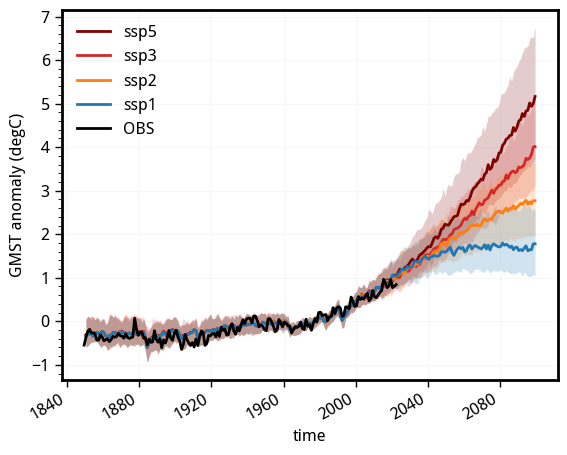

In [40]:
ts5.gmst.quantile(0.5, 'model').plot(color='maroon', lw=2.0, label='ssp5')
plt.fill_between(ts5.time.to_numpy(), ts5.gmst.quantile(0.1, 'model'), ts5.gmst.quantile(0.9, 'model'), color='maroon', alpha=0.2, lw=0.)

ts3.gmst.quantile(0.5 ,'model').plot(color='tab:red', lw=2.0, label='ssp3')
plt.fill_between(ts3.time.to_numpy(), ts3.gmst.quantile(0.1, 'model'), ts3.gmst.quantile(0.9, 'model'), color='tab:red', alpha=0.2, lw=0.)

ts2.gmst.quantile(0.5, 'model').plot(color='tab:orange', lw=2.0, label='ssp2')
plt.fill_between(ts2.time.to_numpy(), ts2.gmst.quantile(0.1, 'model'), ts2.gmst.quantile(0.9, 'model'), color='tab:orange', alpha=0.2, lw=0.)

ts1.gmst.quantile(0.5, 'model').plot(color='tab:blue', lw=2.0, label='ssp1')
plt.fill_between(ts1.time.to_numpy(), ts1.gmst.quantile(0.1, 'model'), ts1.gmst.quantile(0.9, 'model'), color='tab:blue', alpha=0.2, lw=0.)

gmst_obs.plot(color='k', ls='-', lw=2.0, label='OBS')
plt.title('')
plt.ylabel('GMST anomaly (degC)')
plt.legend(frameon=False, fontsize=12)
plot_decorator()


In [41]:
ts5_ext = ts5_ext.sel(time = slice('1850', '2299'))
ts1_ext = ts1_ext.sel(time = slice('1850', '2299'))
ts5o_ext = ts5o_ext.sel(time = slice('1850', '2299'))

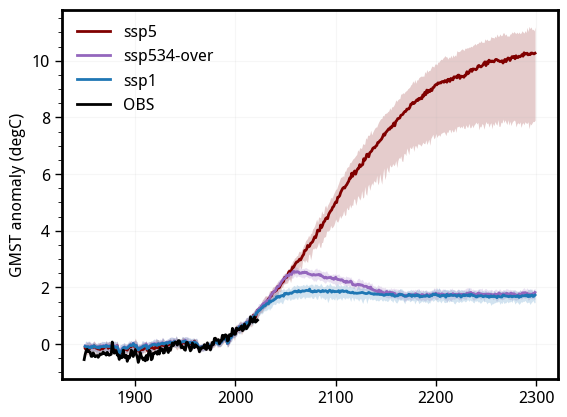

In [42]:

plt.plot(ts5_ext.time.dt.year, ts5_ext.gmst.quantile(0.5, 'model'), color='maroon', lw=2.0, label='ssp5')
plt.fill_between(ts5_ext.time.dt.year, ts5_ext.gmst.quantile(0.1, 'model'), ts5_ext.gmst.quantile(0.9, 'model'), color='maroon', alpha=0.2, lw=0.)

plt.plot(ts5o_ext.time.dt.year, ts5o_ext.gmst.quantile(0.5, 'model'), color='tab:purple', lw=2.0, label='ssp534-over')
plt.fill_between(ts5o_ext.time.dt.year, ts5o_ext.gmst.quantile(0.1, 'model'), ts5o_ext.gmst.quantile(0.9, 'model'), color='tab:purple', alpha=0.2, lw=0.)

plt.plot(ts1_ext.time.dt.year, ts1_ext.gmst.quantile(0.5, 'model'), color='tab:blue', lw=2.0, label='ssp1')
plt.fill_between(ts1_ext.time.dt.year, ts1_ext.gmst.quantile(0.1, 'model'), ts1_ext.gmst.quantile(0.9, 'model'), color='tab:blue', alpha=0.2, lw=0.)

plt.plot(gmst_obs.time.dt.year, gmst_obs, color='k', ls='-', lw=2.0, label='OBS')
plt.title('')
plt.ylabel('GMST anomaly (degC)')
plt.legend(frameon=False, fontsize=12)
plot_decorator()

In [43]:
psl5_noanom = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp5_noanom.nc')

In [44]:
so_warming1 = ts1.so_sst.sel(time = slice('2050', '2100')).mean('time')
np_warming1 = ts1.np_sst.sel(time = slice('2050', '2100')).mean('time')
gmst_warming1 = ts1.gmst.sel(time = slice('2050', '2100')).mean('time')
sst_grad1 = ts1.wp_sst - ts1.ep_sst
grad_weakening1 = sst_grad1.sel(time = slice('2050', '2100')).mean('time')

In [45]:
so_warming2 = ts2.so_sst.sel(time = slice('2050', '2100')).mean('time')
np_warming2 = ts2.np_sst.sel(time = slice('2050', '2100')).mean('time')
gmst_warming2 = ts2.gmst.sel(time = slice('2050', '2100')).mean('time')
sst_grad2 = ts2.wp_sst - ts2.ep_sst
grad_weakening2 = sst_grad2.sel(time = slice('2050', '2100')).mean('time')

In [46]:
so_warming3 = ts3.so_sst.sel(time = slice('2050', '2100')).mean('time')
np_warming3 = ts3.np_sst.sel(time = slice('2050', '2100')).mean('time')
gmst_warming3 = ts3.gmst.sel(time = slice('2050', '2100')).mean('time')
sst_grad3 = ts3.wp_sst - ts3.ep_sst
grad_weakening3 = sst_grad3.sel(time = slice('2050', '2100')).mean('time')

In [47]:
so_warming5 = ts5.so_sst.sel(time = slice('2050', '2100')).mean('time')
np_warming5 = ts5.np_sst.sel(time = slice('2050', '2100')).mean('time')
gmst_warming5 = ts5.gmst.sel(time = slice('2050', '2100')).mean('time')
sst_grad5 = ts5.wp_sst - ts5.ep_sst
grad_weakening5 = sst_grad5.sel(time = slice('2050', '2100')).mean('time')

In [48]:
so_warming5o = ts5o_ext.so_sst.sel(time = slice('2050', '2100')).mean('time')
np_warming5o = ts5o_ext.np_sst.sel(time = slice('2050', '2100')).mean('time')
gmst_warming5o = ts5o_ext.gmst.sel(time = slice('2050', '2100')).mean('time')
sst_grad5o = ts5o_ext.wp_sst - ts5o_ext.ep_sst
grad_weakening5o = sst_grad5o.sel(time = slice('2050', '2100')).mean('time')

In [49]:
so_warming = np.concatenate((so_warming1, so_warming2, so_warming3, so_warming5o, so_warming5))
np_warming = np.concatenate((np_warming1, np_warming2, np_warming3, np_warming5o, np_warming5))
grad_weakening = np.concatenate((grad_weakening1, grad_weakening2, grad_weakening3, grad_weakening5o, grad_weakening5))
gmst_warming = np.concatenate((gmst_warming1, gmst_warming2, grad_weakening3, gmst_warming5o, gmst_warming5))

In [50]:
# out5_ext.nino34_index.rolling(time = 30).std('time').mean('model').plot(color='maroon')
# plt.fill_between(out5_ext.time.to_numpy(), out5_ext.nino34_index.rolling(time = 30).std('time').mean('model') + out5_ext.nino34_index.rolling(time = 30).std('time').std('model'), out5_ext.nino34_index.rolling(time = 30).std('time').mean('model') - out5_ext.nino34_index.rolling(time = 30).std('time').std('model'), color='maroon', alpha=0.2, lw=0.)

# out5o_ext.nino34_index.rolling(time = 30).std('time').mean('model').plot(color='tab:green')
# plt.fill_between(out5o_ext.time.to_numpy(), out5o_ext.nino34_index.rolling(time = 30).std('time').mean('model') + out5o_ext.nino34_index.rolling(time = 30).std('time').std('model'), out5o_ext.nino34_index.rolling(time = 30).std('time').mean('model') - out5o_ext.nino34_index.rolling(time = 30).std('time').std('model'), color='tab:green', alpha=0.2, lw=0.)

# # out2.nino34_index.rolling(time = 30).std('time').mean('model').plot(color='tab:orange')
# # plt.fill_between(out2.time.to_numpy(), out2.nino34_index.rolling(time = 30).std('time').mean('model') + out2.nino34_index.rolling(time = 30).std('time').std('model'), out2.nino34_index.rolling(time = 30).std('time').mean('model') - out2.nino34_index.rolling(time = 30).std('time').std('model'), color='tab:orange', alpha=0.2, lw=0.)

# out1_ext.nino34_index.rolling(time = 30).std('time').mean('model').plot(color='tab:blue')
# plt.fill_between(out1_ext.time.to_numpy(), out1_ext.nino34_index.rolling(time = 30).std('time').mean('model') + out1_ext.nino34_index.rolling(time = 30).std('time').std('model'), out1_ext.nino34_index.rolling(time = 30).std('time').mean('model') - out1_ext.nino34_index.rolling(time = 30).std('time').std('model'), color='tab:blue', alpha=0.2, lw=0.)

In [51]:
# test0 = (ts5.np_sst - ts5.so_sst).sel(time = slice('2000', '2014')).mean('time') - (ts5.np_sst - ts5.so_sst).sel(time = slice('1950', '1970')).mean('time')
hist_mean_state_changes = sst_grad5.sel(time = slice('2000', '2014')).mean('time') - sst_grad5.sel(time = slice('1850', '1900')).mean('time')
early_changes = sst_grad5.sel(time = slice('2015', '2035')).mean('time')
mid_changes = sst_grad5.sel(time = slice('2040', '2070')).mean('time')
late_changes = sst_grad5.sel(time = slice('2080', '2100')).mean('time')


In [52]:
df = pd.DataFrame(data=dict(hist=hist_mean_state_changes.to_numpy(), early = early_changes.to_numpy(), med=mid_changes.to_numpy(), late = late_changes.to_numpy()))

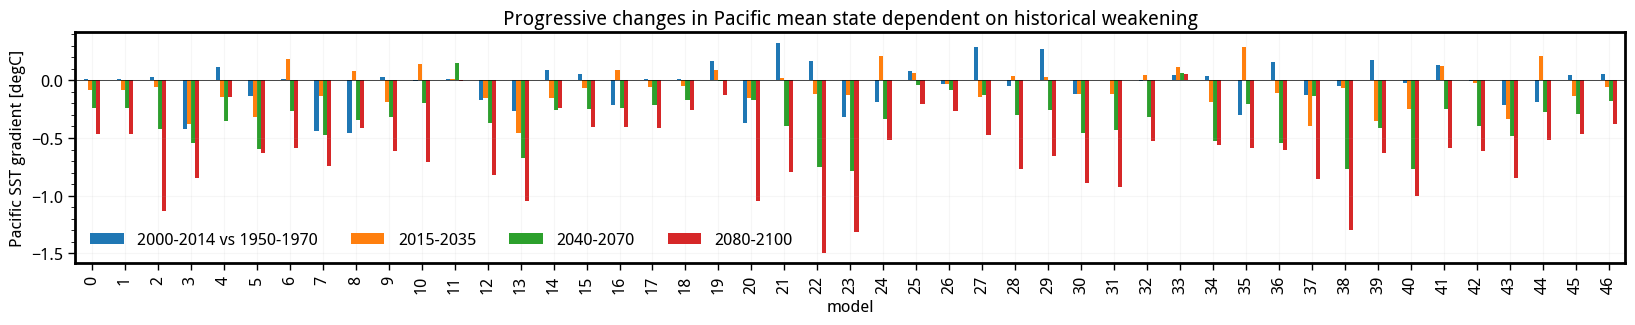

In [53]:
df.plot.bar(figsize=(20,3))
plt.xlabel('model')
plt.ylabel('Pacific SST gradient [degC]')
plt.title('Progressive changes in Pacific mean state dependent on historical weakening')
ax = plt.gca()
ax.legend(["2000-2014 vs 1950-1970", "2015-2035", "2040-2070", "2080-2100"], frameon=False, ncol=5)
plt.axhline(0.0, lw=0.5, color='k')
plot_decorator()

In [56]:
weights = np.cos(np.deg2rad(ts5.ts.lat))
weights

<xarray.DataArray 'lat' (lat: 120)>
array([0.0130896 , 0.03925982, 0.06540313, 0.09150162, 0.1175374 ,
       0.14349262, 0.1693495 , 0.19509032, 0.22069744, 0.24615329,
       0.27144045, 0.29654157, 0.32143947, 0.34611706, 0.37055744,
       0.39474386, 0.41865974, 0.44228869, 0.46561452, 0.48862124,
       0.51129309, 0.53361452, 0.55557023, 0.57714519, 0.5983246 ,
       0.61909395, 0.639439  , 0.65934582, 0.67880075, 0.69779046,
       0.71630194, 0.73432251, 0.75183981, 0.76884183, 0.78531693,
       0.80125381, 0.81664156, 0.83146961, 0.84572782, 0.85940641,
       0.87249601, 0.88498764, 0.89687274, 0.90814317, 0.91879121,
       0.92880955, 0.93819134, 0.94693013, 0.95501994, 0.96245524,
       0.96923091, 0.97534232, 0.98078528, 0.98555606, 0.98965139,
       0.99306846, 0.99580493, 0.99785892, 0.99922904, 0.99991433,
       0.99991433, 0.99922904, 0.99785892, 0.99580493, 0.99306846,
       0.98965139, 0.98555606, 0.98078528, 0.97534232, 0.96923091,
       0.96245524, 0.95501994, 0.94693013, 0.93819134, 0.92880955,
       0.91879121, 0.90814317, 0.89687274, 0.88498764, 0.87249601,
       0.85940641, 0.84572782, 0.83146961, 0.81664156, 0.80125381,
       0.78531693, 0.76884183, 0.75183981, 0.73432251, 0.71630194,
       0.69779046, 0.67880075, 0.65934582, 0.639439  , 0.61909395,
       0.5983246 , 0.57714519, 0.55557023, 0.53361452, 0.51129309,
       0.48862124, 0.46561452, 0.44228869, 0.41865974, 0.39474386,
       0.37055744, 0.34611706, 0.32143947, 0.29654157, 0.27144045,
       0.24615329, 0.22069744, 0.19509032, 0.1693495 , 0.14349262,
       0.1175374 , 0.09150162, 0.06540313, 0.03925982, 0.0130896 ])
Coordinates:
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [57]:
def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, cbar_orientation='vertical', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160)):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i])
        if draw_winds:
            axlist[i].quiver(x[::3, ::3], y[::3, ::3], u_wnd[i].to_numpy()[::3, ::3], v_wnd[i].to_numpy()[::3, ::3], scale=wind_scale, color='k', transform=ccrs.PlateCarree())
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0))
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':12})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
    norm = BM(levels, 256, extend='both')
    fig.colorbar(m.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = cbar_orientation, shrink=0.8, aspect = 45, pad = 0.05, label = cbar_label)

In [58]:
import regionmask

In [59]:
land_mask = regionmask.defined_regions.natural_earth_v5_0_0.land_10.mask_3D(ts5.ts)

In [66]:
ts5_land = ts5.where(~land_mask).squeeze()

In [67]:
plot_list = [
    ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)),
    ts5_land.ts.where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)),
    ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)),
    ts5_land.ts.where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)),
    ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)),
    ts5_land.ts.where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)),
    ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2000', '2014')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)),
    ts5_land.ts.where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2000', '2014')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)),
]


In [68]:
titles_list = [
    '',
    '',
    '',
    '',
    '',
    '',
    '',
    '',
]

In [69]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

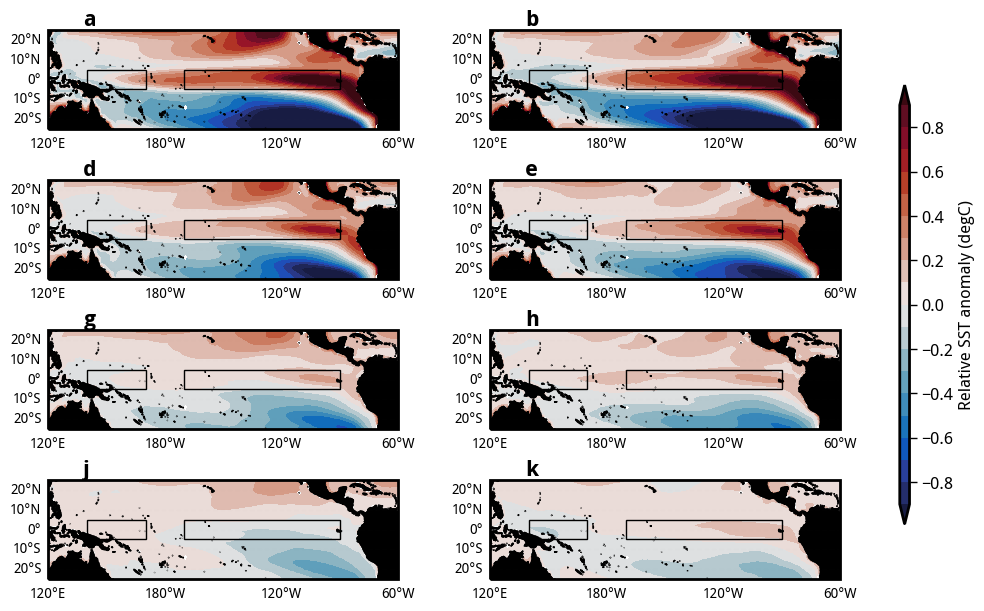

In [70]:
plot_maps(xx, yy, [x - x.mean(('lat', 'lon')) for x in plot_list], titles_list, labels=['a', 'b', 'd', 'e', 'g', 'h', 'j', 'k'], cmap=cmocean.cm.balance, levels=np.arange(-0.9, 1.0, 0.1), cbar_label = 'Relative SST anomaly (degC)', pval = [], nrows=4, ncols=2, figsize=(10,6), land_mask_list = np.arange(0, 12, 1), add_patch=True, cbar_orientation='vertical', proj = ccrs.Mercator(central_longitude=160))

In [71]:
plot_list = [
    ts5_land.ts.where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)) - ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)),
    ts5_land.ts.where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)) - ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)),
    ts5_land.ts.where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)) - ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)),
    ts5_land.ts.where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2000', '2014')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)) - ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2000', '2014')).mean(('time', 'model')).sel(lat = slice(-25, 25), lon = slice(120, 300)),
]


In [72]:
titles_list = [
    '',
    '',
    '',
    '',
]

In [73]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

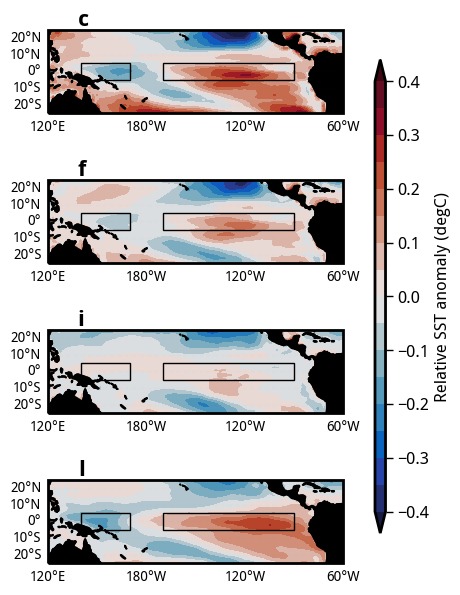

In [108]:
plot_maps(xx, yy, [x - x.mean(('lat', 'lon')) for x in plot_list], titles_list, labels=['c', 'f', 'i', 'l'], cmap=cmocean.cm.balance, levels=np.arange(-0.4, 0.45, 0.05), cbar_label = 'Relative SST anomaly (degC)', pval = [], nrows=4, ncols=1, figsize=(4.5,6), land_mask_list = np.arange(0, 5, 1), add_patch=True, cbar_orientation='vertical', proj = ccrs.Mercator(central_longitude=160))

In [82]:
plot_list = [
    ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2000', '2014')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2000', '2014')).mean(('time', 'model')),
]

In [87]:
titles_list = [
    '',
    '',
    '',
    '',
    '',
    '',
    '',
    '',
]

In [88]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

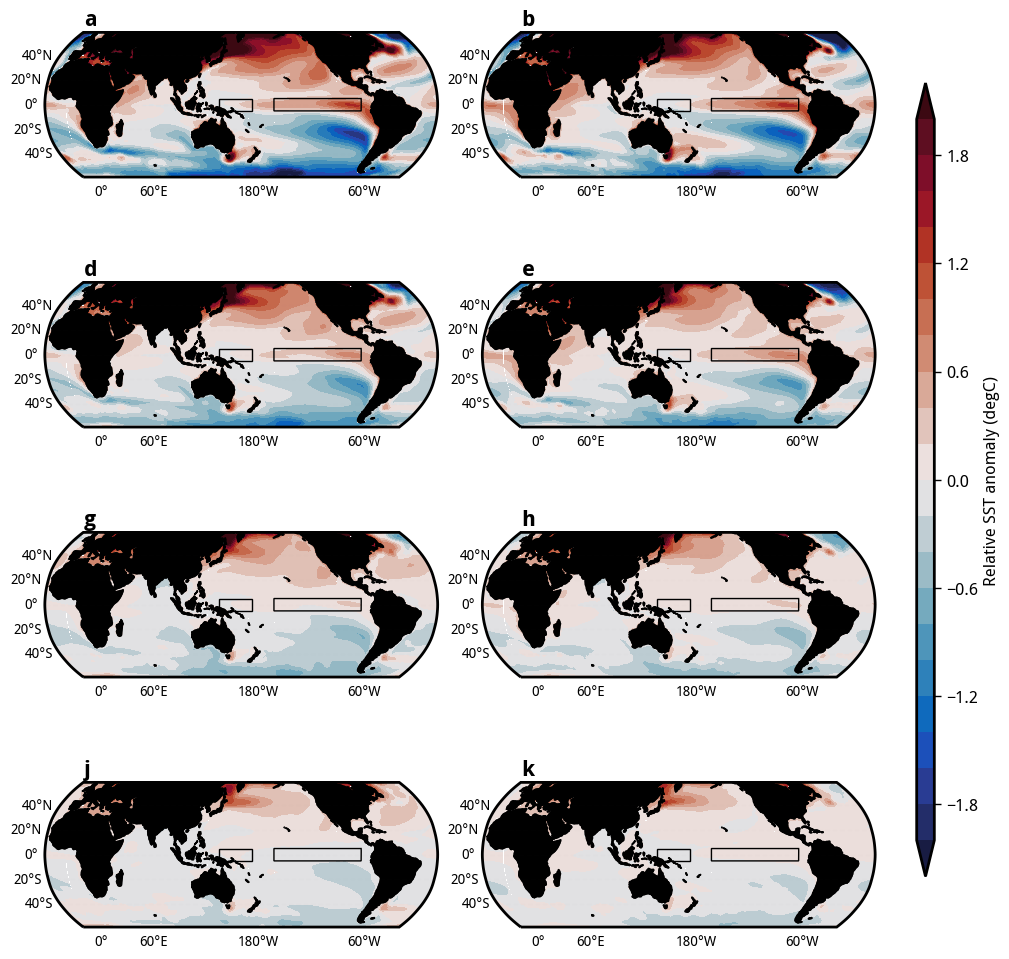

In [89]:
plot_maps(xx, yy, [x - x.mean(('lat', 'lon')) for x in plot_list], titles_list, labels=['a', 'b', 'd', 'e', 'g', 'h', 'j', 'k'], cmap=cmocean.cm.balance, levels=np.arange(-2.0, 2.2, 0.2), cbar_label = 'Relative SST anomaly (degC)', pval = [], nrows=4, ncols=2, figsize=(10,10), land_mask_list = np.arange(0, 8), add_patch=True, cbar_orientation='vertical', proj = ccrs.Robinson(central_longitude=160))

In [94]:
plot_list = [
    ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')) - ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')) - ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')) - ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2000', '2014')).mean(('time', 'model')) - ts5_land.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2000', '2014')).mean(('time', 'model')),
]

In [ ]:
# pval_list = [
#     funcs.mannwhitneyu3d(ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model'), drop=True).sel(time = slice('2080', '2100')).mean(('time')), ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model'), drop=True).sel(time = slice('2080', '2100')).mean(('time')), dim='model'),
#     funcs.mannwhitneyu3d(ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model'), drop=True).sel(time = slice('2040', '2070')).mean(('time')), ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model'), drop=True).sel(time = slice('2040', '2070')).mean(('time')), dim='model'),
#     funcs.mannwhitneyu3d(ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model'), drop=True).sel(time = slice('2015', '2035')).mean(('time')), ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model'), drop=True).sel(time = slice('2015', '2035')).mean(('time')), dim='model'),
# ]

In [92]:
titles_list = [
    '',
    '',
    '',
    '',
]

In [93]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

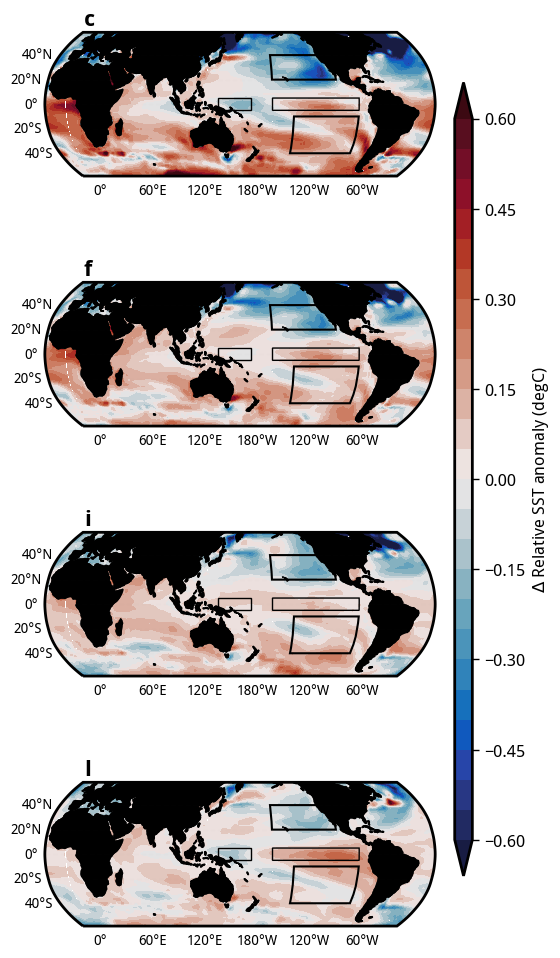

In [96]:
plot_maps(xx, yy, [x - x.mean(('lat', 'lon')) for x in plot_list], titles_list, labels=['c', 'f', 'i', 'l'], cmap=cmocean.cm.balance, levels=np.arange(-0.6, 0.65, 0.05), cbar_label = r'$\Delta$ Relative SST anomaly (degC)', pval = [], nrows=4, ncols=1, figsize=(5.5,10), land_mask_list = np.arange(0,4), add_patch=True, add_patch_extra=True, cbar_orientation='vertical', proj = ccrs.Robinson(central_longitude=160))

In [114]:
plot_list = [
    ts5_land.ts.sel(lat = slice(-20, 90)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')) - ts5_land.ts.sel(lat = slice(-20, 90)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-20, 90)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')) - ts5_land.ts.sel(lat = slice(-20, 90)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-20, 90)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')) - ts5_land.ts.sel(lat = slice(-20, 90)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-20, 90)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2000', '2014')).mean(('time', 'model')) - ts5_land.ts.sel(lat = slice(-20, 90)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2000', '2014')).mean(('time', 'model')),
]

In [115]:
# pval_list = [
#     funcs.mannwhitneyu3d(ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model'), drop=True).sel(time = slice('2080', '2100')).mean(('time')), ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model'), drop=True).sel(time = slice('2080', '2100')).mean(('time')), dim='model'),
#     funcs.mannwhitneyu3d(ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model'), drop=True).sel(time = slice('2040', '2070')).mean(('time')), ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model'), drop=True).sel(time = slice('2040', '2070')).mean(('time')), dim='model'),
#     funcs.mannwhitneyu3d(ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model'), drop=True).sel(time = slice('2015', '2035')).mean(('time')), ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model'), drop=True).sel(time = slice('2015', '2035')).mean(('time')), dim='model'),
# ]

In [116]:
titles_list = [
    '',
    '',
    '',
    '',
]

In [117]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

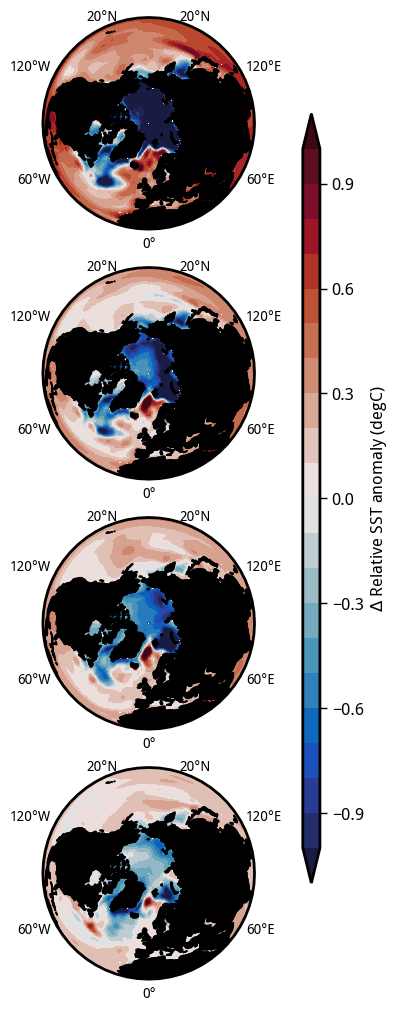

In [118]:
plot_maps(xx, yy, [x - x.mean(('lat', 'lon')) for x in plot_list], titles_list, labels=titles_list, cmap=cmocean.cm.balance, levels=np.arange(-1.0, 1.1, 0.1), cbar_label = r'$\Delta$ Relative SST anomaly (degC)', pval = [], nrows=4, ncols=1, figsize=(5.5,10), land_mask_list = np.arange(0,4), add_patch=False, add_patch_extra=False, cbar_orientation='vertical', proj = ccrs.Orthographic(central_longitude=0, central_latitude=90))

In [119]:
plot_list = [
    ts5_land.ts.sel(lat = slice(-90, 20)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')) - ts5_land.ts.sel(lat = slice(-90, 20)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-90, 20)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')) - ts5_land.ts.sel(lat = slice(-90, 20)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-90, 20)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')) - ts5_land.ts.sel(lat = slice(-90, 20)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')),
    ts5_land.ts.sel(lat = slice(-90, 20)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2000', '2014')).mean(('time', 'model')) - ts5_land.ts.sel(lat = slice(-90, 20)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2000', '2014')).mean(('time', 'model')),
]

In [120]:
# pval_list = [
#     funcs.mannwhitneyu3d(ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model'), drop=True).sel(time = slice('2080', '2100')).mean(('time')), ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model'), drop=True).sel(time = slice('2080', '2100')).mean(('time')), dim='model'),
#     funcs.mannwhitneyu3d(ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model'), drop=True).sel(time = slice('2040', '2070')).mean(('time')), ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model'), drop=True).sel(time = slice('2040', '2070')).mean(('time')), dim='model'),
#     funcs.mannwhitneyu3d(ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model'), drop=True).sel(time = slice('2015', '2035')).mean(('time')), ts5.ts.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model'), drop=True).sel(time = slice('2015', '2035')).mean(('time')), dim='model'),
# ]

In [121]:
titles_list = [
    '',
    '',
    '',
    '',
]

In [122]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

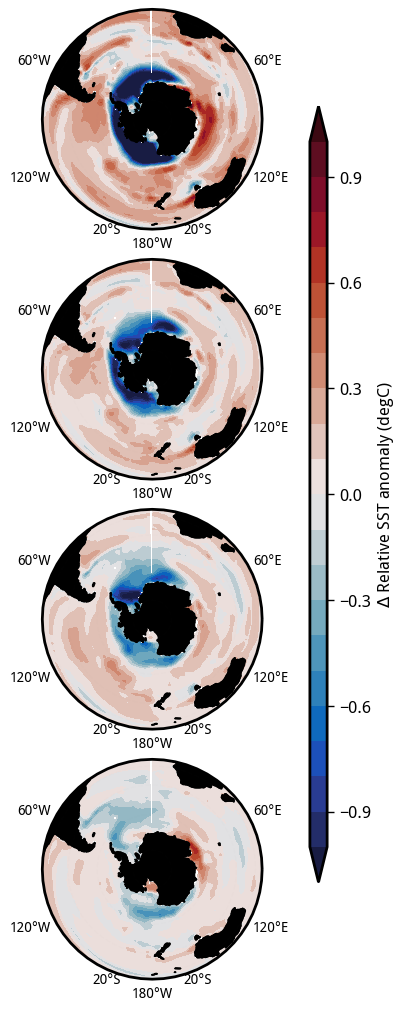

In [123]:
plot_maps(xx, yy, [x - x.mean(('lat', 'lon')) for x in plot_list], titles_list, labels=titles_list, cmap=cmocean.cm.balance, levels=np.arange(-1.0, 1.1, 0.1), cbar_label = r'$\Delta$ Relative SST anomaly (degC)', pval = [], nrows=4, ncols=1, figsize=(5.5,10), land_mask_list = np.arange(0,4), add_patch=False, add_patch_extra=False, cbar_orientation='vertical', proj = ccrs.Orthographic(central_longitude=0, central_latitude=-90))

In [121]:
uas5 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/uas_ssp5.nc')

In [122]:
vas5 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/vas_ssp5.nc')

In [123]:
uas5_anom = funcs.calc_anom(uas5.uas, uas5.uas.sel(time = slice('1960', '1990')))
vas5_anom = funcs.calc_anom(vas5.vas, vas5.vas.sel(time = slice('1960', '1990')))

In [161]:
plot_list = [
    psl5.psl.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')),
    psl5.psl.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')),
    psl5.psl.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')),
    psl5.psl.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')),
    psl5.psl.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')),
    psl5.psl.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')),
]

In [162]:
uwnd_list = [
    uas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')),
    uas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')),
    uas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')),
    uas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')),
    uas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')),
    uas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')),
]

In [163]:
vwnd_list = [
    vas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')),
    vas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')),
    vas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')),
    vas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')),
    vas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')),
    vas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')),
]

In [164]:
contour_data = [
    (psl5_noanom.psl.sel(lat = slice(-60, 60)).sel(time = slice('1850', '1900')).mean(('time', 'model'))/100 - 1015),
    (psl5_noanom.psl.sel(lat = slice(-60, 60)).sel(time = slice('1850', '1900')).mean(('time', 'model'))/100 - 1015),
    (psl5_noanom.psl.sel(lat = slice(-60, 60)).sel(time = slice('1850', '1900')).mean(('time', 'model'))/100 - 1015),
    (psl5_noanom.psl.sel(lat = slice(-60, 60)).sel(time = slice('1850', '1900')).mean(('time', 'model'))/100 - 1015),
    (psl5_noanom.psl.sel(lat = slice(-60, 60)).sel(time = slice('1850', '1900')).mean(('time', 'model'))/100 - 1015),
    (psl5_noanom.psl.sel(lat = slice(-60, 60)).sel(time = slice('1850', '1900')).mean(('time', 'model'))/100 - 1015),
]

In [165]:
titles_list = [
    '',
    '',
    '',
    '',
    '',
    '',
]

In [166]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

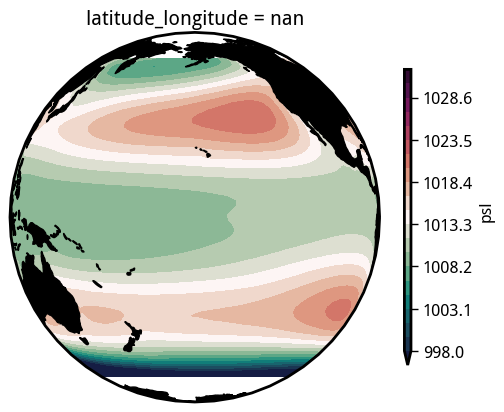

In [176]:
ax = plt.axes(projection=ccrs.Orthographic(central_longitude=200))
(psl5_noanom.psl/100).sel(time = slice('1850', '1900'), lat = slice(-60, 60)).mean(('model', 'time')).plot.contourf(vmin=998, center=1015, levels=21, cmap=cmocean.cm.curl, transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', aspect=45, shrink=0.8))
ax.add_feature(cfeature.LAND, color='k', zorder=1)

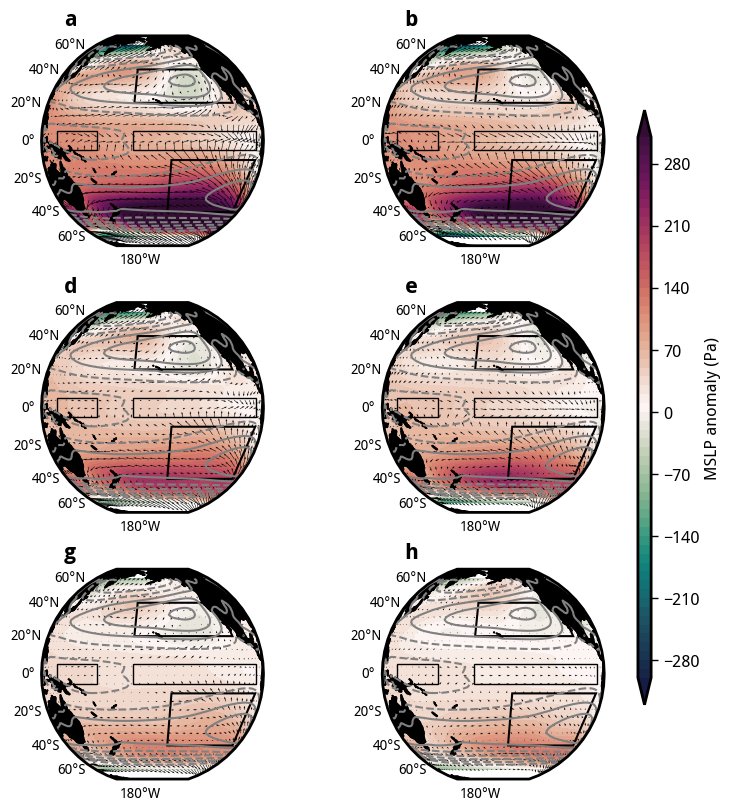

In [167]:
plot_maps(xx, yy, plot_list, titles_list, labels=['a', 'b', 'd', 'e', 'g', 'h'], cmap=cmocean.cm.curl, levels=np.arange(-300, 320, 10), cbar_label = 'MSLP anomaly (Pa)', pval = [], draw_winds=True, u_wnd=uwnd_list, v_wnd=vwnd_list, wind_scale=17, draw_contour=True, contour_data=contour_data, contour_levels=np.arange(-15, 18, 3), contour_colors='gray', nrows=3, ncols=2, figsize=(8,8), land_mask_list = np.arange(0, 6, 1), add_patch=True, add_patch_extra=True, cbar_orientation='vertical', proj=ccrs.Orthographic(central_longitude=200))

In [168]:
plot_list = [
    psl5.psl.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')) - psl5.psl.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')),
    psl5.psl.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')) - psl5.psl.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')),
    psl5.psl.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')) - psl5.psl.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')),
]

In [169]:
uwnd_list = [
    uas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')) - uas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')),
    uas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')) - uas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')),
    uas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')) - uas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')),
]

In [170]:
vwnd_list = [
    vas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')) - vas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2080', '2100')).mean(('time', 'model')),
    vas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')) - vas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2040', '2070')).mean(('time', 'model')),
    vas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')) - vas5_anom.sel(lat = slice(-60, 60)).where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75, 'model')).sel(time = slice('2015', '2035')).mean(('time', 'model')),
]

In [171]:
titles_list = [
    '',
    '',
    '',
]

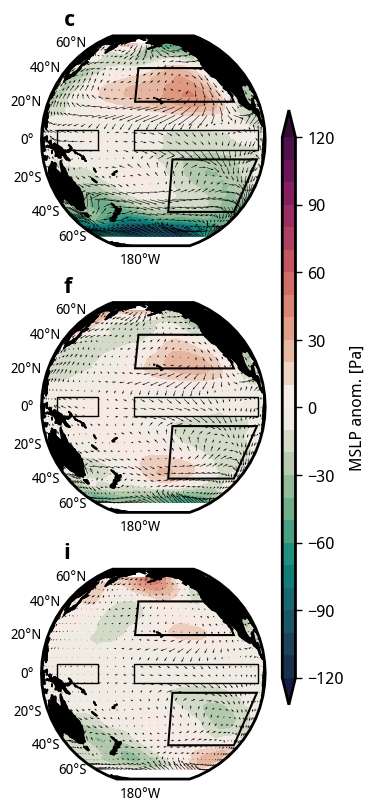

In [172]:
plot_maps(xx, yy, plot_list, titles_list, labels=['c', 'f', 'i'], cmap=cmocean.cm.curl, levels=np.arange(-120, 130, 10), cbar_label = 'MSLP anom. [Pa]', pval = [], draw_winds=True, u_wnd=uwnd_list, v_wnd=vwnd_list, wind_scale=12, nrows=3, ncols=1, figsize=(4.5,8), land_mask_list = np.arange(0, 3, 1), add_patch=True, add_patch_extra=True, cbar_orientation='vertical', hatch_type='insig', proj=ccrs.Orthographic(central_longitude=200))

## model comparison

In [177]:
rel_ts5 = (ts5.ts - ts5.ts.mean(('lat', 'lon')))

In [54]:
# ar6_ocean = regionmask.defined_regions.ar6.ocean.mask_3D(rel_ts5)
# ar6_ocean

In [124]:
late_response_indian = ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75)).sel(lat = slice(-40, 0), lon = slice(20, 120)).weighted(weights).mean(('lat', 'lon')).squeeze()
late_response_sp = ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75)).sel(lat = slice(-40, -20), lon = slice(120, 300)).weighted(weights).mean(('lat', 'lon')).squeeze()
late_response_np = ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75)).sel(lat = slice(20, 40), lon = slice(120, 300)).weighted(weights).mean(('lat', 'lon')).squeeze()
late_response_sa = ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75)).sel(lat = slice(-40, -20), lon = slice(120, 300)).weighted(weights).mean(('lat', 'lon')).squeeze()
late_response_na = ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75)).sel(lat = slice(20, 40), lon = slice(310, 350)).weighted(weights).mean(('lat', 'lon')).squeeze()

In [129]:
early_response_indian = ts5.ts.where(~land_mask).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25)).sel(lat = slice(-40, 0), lon = slice(20, 120)).weighted(weights).mean(('lat', 'lon')).squeeze()
early_response_sp = ts5.ts.where(~land_mask).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25)).sel(lat = slice(-40, -20), lon = slice(120, 300)).weighted(weights).mean(('lat', 'lon')).squeeze()
early_response_np = ts5.ts.where(~land_mask).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25)).sel(lat = slice(20, 40), lon = slice(120, 300)).weighted(weights).mean(('lat', 'lon')).squeeze()
early_response_sa = ts5.ts.where(~land_mask).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25)).sel(lat = slice(-40, -20), lon = slice(120, 300)).weighted(weights).mean(('lat', 'lon')).squeeze()
early_response_na = ts5.ts.where(~land_mask).where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25)).sel(lat = slice(20, 40), lon = slice(310, 350)).weighted(weights).mean(('lat', 'lon')).squeeze()

In [150]:
late_response_nonpolar = ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75)).sel(lat = slice(-55, 55)).weighted(weights).mean(('lat', 'lon')).squeeze()
early_response_nonpolar = ts5_land.ts.where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25)).sel(lat = slice(-55, 55)).weighted(weights).mean(('lat', 'lon')).squeeze()

In [144]:
late_response_global_full = ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75)).weighted(weights).mean(('lat', 'lon')).squeeze()
early_response_global_full = ts5_land.ts.where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25)).weighted(weights).mean(('lat', 'lon')).squeeze()

In [151]:
late_response_polar_nh = ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75)).sel(lat = slice(70, 90)).weighted(weights).mean(('lat', 'lon')).squeeze()
early_response_polar_nh = ts5_land.ts.where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25)).sel(lat = slice(70, 90)).weighted(weights).mean(('lat', 'lon')).squeeze()

late_response_polar_sh = ts5_land.ts.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75)).sel(lat = slice(-90, -70)).weighted(weights).mean(('lat', 'lon')).squeeze()
early_response_polar_sh = ts5_land.ts.where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25)).sel(lat = slice(-90, -70)).weighted(weights).mean(('lat', 'lon')).squeeze()

In [130]:
late_response_grad = loess3d(sst_grad5.where(hist_mean_state_changes > hist_mean_state_changes.quantile(0.75), drop=True), period=5, dim='time').squeeze()
early_response_grad = loess3d(sst_grad5.where(hist_mean_state_changes < hist_mean_state_changes.quantile(0.25), drop=True), period=5, dim='time').squeeze()


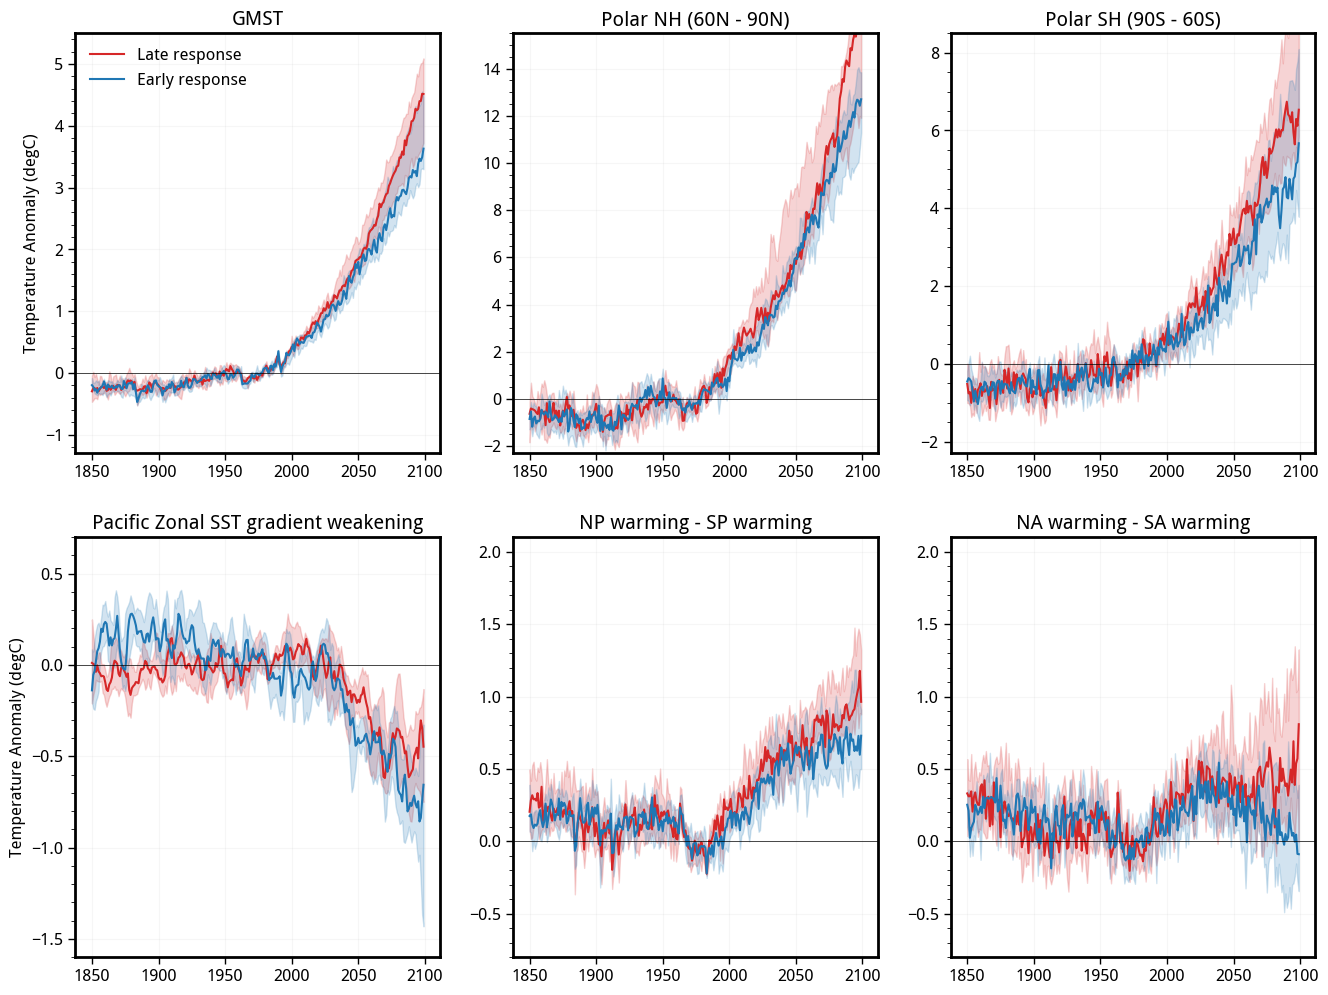

In [155]:
timex = late_response_grad.time.dt.year

plt.figure(figsize=(16, 12))

plt.subplot(231)
plt.plot(timex, late_response_global_full.quantile(0.5, 'model'), color='tab:red', label='Late response')
plt.fill_between(timex, late_response_global_full.quantile(0.25, 'model'), late_response_global_full.quantile(0.75, 'model'), alpha=0.2, color='tab:red')
plt.plot(timex, early_response_global_full.quantile(0.5, 'model'), color='tab:blue', label='Early response')
plt.fill_between(timex, early_response_global_full.quantile(0.25, 'model'), early_response_global_full.quantile(0.75, 'model'), alpha=0.2, color='tab:blue')
plt.ylim(-1.3, 5.5)
plt.title('GMST')
plt.legend(frameon=False, fontsize=12, loc='upper left')
plot_decorator()
plt.ylabel('Temperature Anomaly (degC)')
plt.axhline(0.0, color='k', lw=0.5)

plt.subplot(232)
plt.plot(timex, late_response_polar_nh.quantile(0.5, 'model'), color='tab:red', label='Late response')
plt.fill_between(timex, late_response_polar_nh.quantile(0.25, 'model'), late_response_polar_nh.quantile(0.75, 'model'), alpha=0.2, color='tab:red')
plt.plot(timex, early_response_polar_nh.quantile(0.5, 'model'), color='tab:blue', label='Early response')
plt.fill_between(timex, early_response_polar_nh.quantile(0.25, 'model'), early_response_polar_nh.quantile(0.75, 'model'), alpha=0.2, color='tab:blue')
plt.ylim(-2.3, 15.5)
plt.title('Polar NH (60N - 90N)')
# plt.legend(frameon=False, fontsize=12)
plot_decorator()
plt.axhline(0.0, color='k', lw=0.5)

plt.subplot(233)
plt.plot(timex, late_response_polar_sh.quantile(0.5, 'model'), color='tab:red', label='Late response')
plt.fill_between(timex, late_response_polar_sh.quantile(0.25, 'model'), late_response_polar_sh.quantile(0.75, 'model'), alpha=0.2, color='tab:red')
plt.plot(timex, early_response_polar_sh.quantile(0.5, 'model'), color='tab:blue', label='Early response')
plt.fill_between(timex, early_response_polar_sh.quantile(0.25, 'model'), early_response_polar_sh.quantile(0.75, 'model'), alpha=0.2, color='tab:blue')
plt.ylim(-2.3, 8.5)
plt.title('Polar SH (90S - 60S)')
# plt.legend(frameon=False, fontsize=12)
plot_decorator()
plt.axhline(0.0, color='k', lw=0.5)


plt.subplot(234)
plt.plot(timex, late_response_grad.quantile(0.5, 'model'), color='tab:red', label='Late/fast response')
plt.fill_between(timex, late_response_grad.quantile(0.25, 'model'), late_response_grad.quantile(0.75, 'model'), alpha=0.2, color='tab:red')
plt.plot(timex, early_response_grad.quantile(0.5, 'model'), color='tab:blue', label='Early/slow response')
plt.fill_between(timex, early_response_grad.quantile(0.25, 'model'), early_response_grad.quantile(0.75, 'model'), alpha=0.2, color='tab:blue')
plt.ylim(-1.6, 0.7)
# plt.legend(frameon=False, fontsize=12)
plot_decorator()
plt.ylabel('Temperature Anomaly (degC)')
plt.title('Pacific Zonal SST gradient weakening')
plt.axhline(0.0, color='k', lw=0.5)

plt.subplot(235)
plt.plot(timex, (late_response_np - late_response_sp).quantile(0.5, 'model'), color='tab:red', label='Late response')
plt.fill_between(timex, (late_response_np - late_response_sp).quantile(0.25, 'model'), (late_response_np - late_response_sp).quantile(0.75, 'model'), alpha=0.2, color='tab:red')
plt.plot(timex, (early_response_np - early_response_sp).quantile(0.5, 'model'), color='tab:blue', label='Early response')
plt.fill_between(timex, (early_response_np - early_response_sp).quantile(0.25, 'model'), (early_response_np - early_response_sp).quantile(0.75, 'model'), alpha=0.2, color='tab:blue')
plt.ylim(-0.8, 2.1)
# plt.legend(frameon=False, fontsize=12)
plt.title('NP warming - SP warming')
plot_decorator()
plt.axhline(0.0, color='k', lw=0.5)

plt.subplot(236)
plt.plot(timex, (late_response_na - late_response_sa).quantile(0.5, 'model'), color='tab:red', label='Late/Fast response')
plt.fill_between(timex, (late_response_na - late_response_sa).quantile(0.25, 'model'), (late_response_na - late_response_sa).quantile(0.75, 'model'), alpha=0.2, color='tab:red')
plt.plot(timex, (early_response_na - early_response_sa).quantile(0.5, 'model'), color='tab:blue', label='Early/slow response')
plt.fill_between(timex, (early_response_na - early_response_sa).quantile(0.25, 'model'), (early_response_na - early_response_sa).quantile(0.75, 'model'), alpha=0.2, color='tab:blue')
plt.ylim(-0.8, 2.1)
# plt.legend(frameon=False, fontsize=12)
plot_decorator()
# plt.ylabel('Temperature Anomaly (degC)')
plt.title('NA warming - SA warming')
plt.axhline(0.0, color='k', lw=0.5)



In [ ]:
ts5_roll = ts5.rolling(time = 30, center=False).mean('time')
ts3_roll = ts3.rolling(time = 30, center=False).mean('time')
ts2_roll = ts2.rolling(time = 30, center=False).mean('time')
ts1_roll = ts1.rolling(time = 30, center=False).mean('time')

Text(0.5, 1.0, 'ssp126')

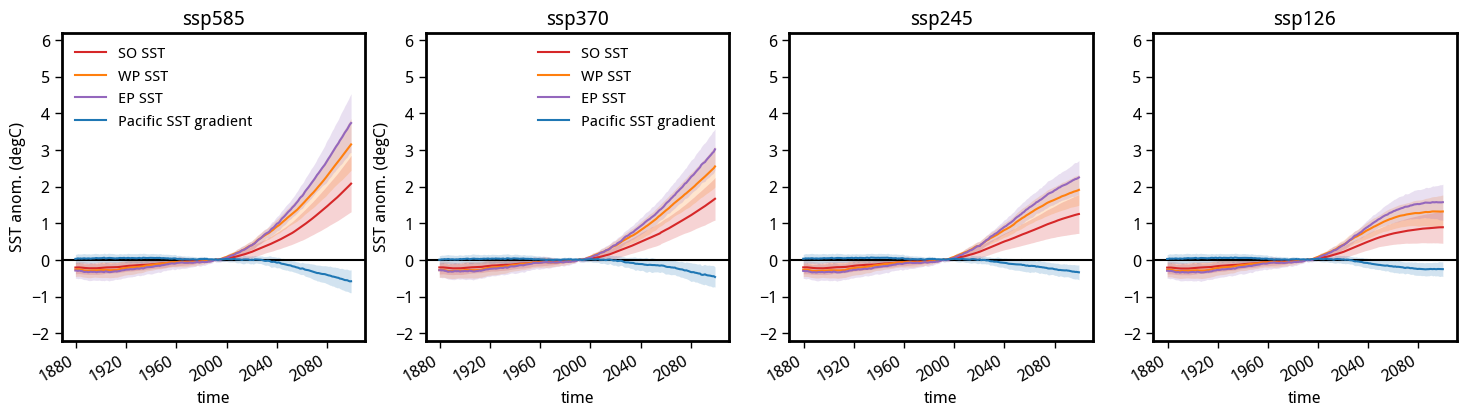

In [ ]:
plt.figure(figsize=(18,4))

plt.subplot(141)
plt.axhline(0.0, color='k')
ts5_roll.so_sst.mean('model').plot(color='tab:red', label='SO SST')
plt.fill_between(ts5_roll.time.to_numpy(), ts5_roll.so_sst.mean('model') + ts5_roll.so_sst.std('model'), ts5_roll.so_sst.mean('model') - ts5_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
ts5_roll.wp_sst.mean('model').plot(color='tab:orange', label='WP SST')
plt.fill_between(ts5_roll.time.to_numpy(), ts5_roll.wp_sst.mean('model') + ts5_roll.wp_sst.std('model'), ts5_roll.wp_sst.mean('model') - ts5_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
ts5_roll.ep_sst.mean('model').plot(color='tab:purple', label='EP SST')
plt.fill_between(ts5_roll.time.to_numpy(), ts5_roll.ep_sst.mean('model') + ts5_roll.ep_sst.std('model'), ts5_roll.ep_sst.mean('model') - ts5_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = ts5_roll.wp_sst - ts5_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue', label='Pacific SST gradient')
plt.fill_between(ts5_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 6.2)
plt.ylabel('SST anom. (degC)')
plt.legend(frameon=False, fontsize=11)
plt.title('ssp585')


plt.subplot(142)
plt.axhline(0.0, color='k')
ts3_roll.so_sst.mean('model').plot(color='tab:red', label='SO SST')
plt.fill_between(ts3_roll.time.to_numpy(), ts3_roll.so_sst.mean('model') + ts3_roll.so_sst.std('model'), ts3_roll.so_sst.mean('model') - ts3_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
ts3_roll.wp_sst.mean('model').plot(color='tab:orange', label='WP SST')
plt.fill_between(ts3_roll.time.to_numpy(), ts3_roll.wp_sst.mean('model') + ts3_roll.wp_sst.std('model'), ts3_roll.wp_sst.mean('model') - ts3_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
ts3_roll.ep_sst.mean('model').plot(color='tab:purple', label='EP SST')
plt.fill_between(ts3_roll.time.to_numpy(), ts3_roll.ep_sst.mean('model') + ts3_roll.ep_sst.std('model'), ts3_roll.ep_sst.mean('model') - ts3_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = ts3_roll.wp_sst - ts3_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue', label='Pacific SST gradient')
plt.fill_between(ts3_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 6.2)
plt.ylabel('SST anom. (degC)')
plt.legend(frameon=False, fontsize=11)
plt.title('ssp370')


plt.subplot(143)
plt.axhline(0.0, color='k')
ts2_roll.so_sst.mean('model').plot(color='tab:red')
plt.fill_between(ts2_roll.time.to_numpy(), ts2_roll.so_sst.mean('model') + ts2_roll.so_sst.std('model'), ts2_roll.so_sst.mean('model') - ts2_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
ts2_roll.wp_sst.mean('model').plot(color='tab:orange')
plt.fill_between(ts2_roll.time.to_numpy(), ts2_roll.wp_sst.mean('model') + ts2_roll.wp_sst.std('model'), ts2_roll.wp_sst.mean('model') - ts2_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
ts2_roll.ep_sst.mean('model').plot(color='tab:purple')
plt.fill_between(ts2_roll.time.to_numpy(), ts2_roll.ep_sst.mean('model') + ts2_roll.ep_sst.std('model'), ts2_roll.ep_sst.mean('model') - ts2_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = ts2_roll.wp_sst - ts2_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue')
plt.fill_between(ts2_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 6.2)
plt.title('ssp245')


plt.subplot(144)
plt.axhline(0.0, color='k')
ts1_roll.so_sst.mean('model').plot(color='tab:red')
plt.fill_between(ts1_roll.time.to_numpy(), ts1_roll.so_sst.mean('model') + ts1_roll.so_sst.std('model'), ts1_roll.so_sst.mean('model') - ts1_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
ts1_roll.wp_sst.mean('model').plot(color='tab:orange')
plt.fill_between(ts1_roll.time.to_numpy(), ts1_roll.wp_sst.mean('model') + ts1_roll.wp_sst.std('model'), ts1_roll.wp_sst.mean('model') - ts1_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
ts1_roll.ep_sst.mean('model').plot(color='tab:purple')
plt.fill_between(ts1_roll.time.to_numpy(), ts1_roll.ep_sst.mean('model') + ts1_roll.ep_sst.std('model'), ts1_roll.ep_sst.mean('model') - ts1_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = ts1_roll.wp_sst - ts1_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue')
plt.fill_between(ts1_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 6.2)
plt.title('ssp126')
# plt.savefig('./images/cmip_mmm.png', dpi=300, bbox_inches='tight')

In [ ]:
ts5_ext_roll = ts5_ext.sel(time = slice('1850','2299')).rolling(time = 30, center=False).mean('time')
ts5o_ext_roll = ts5o_ext.sel(time = slice('1850','2299')).rolling(time = 30, center=False).mean('time')
ts1_ext_roll = ts1_ext.sel(time = slice('1850','2299')).rolling(time = 30, center=False).mean('time')

2025-04-11 00:09:17,901 [WARNING]: legend.py(_parse_legend_args:1217) >> No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 1.0, 'ssp126 extensions')

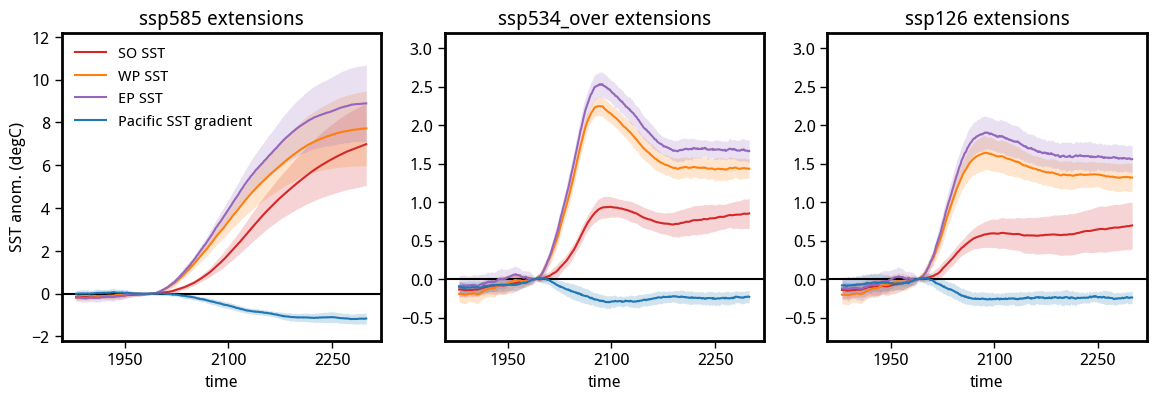

In [ ]:
plt.figure(figsize=(14,4))

plt.subplot(131)
plt.axhline(0.0, color='k')
ts5_ext_roll.so_sst.mean('model').plot(color='tab:red', label='SO SST')
plt.fill_between(ts5_ext_roll.time.to_numpy(), ts5_ext_roll.so_sst.mean('model') + ts5_ext_roll.so_sst.std('model'), ts5_ext_roll.so_sst.mean('model') - ts5_ext_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
ts5_ext_roll.wp_sst.mean('model').plot(color='tab:orange', label='WP SST')
plt.fill_between(ts5_ext_roll.time.to_numpy(), ts5_ext_roll.wp_sst.mean('model') + ts5_ext_roll.wp_sst.std('model'), ts5_ext_roll.wp_sst.mean('model') - ts5_ext_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
ts5_ext_roll.ep_sst.mean('model').plot(color='tab:purple', label='EP SST')
plt.fill_between(ts5_ext_roll.time.to_numpy(), ts5_ext_roll.ep_sst.mean('model') + ts5_ext_roll.ep_sst.std('model'), ts5_ext_roll.ep_sst.mean('model') - ts5_ext_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = ts5_ext_roll.wp_sst - ts5_ext_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue', label='Pacific SST gradient')
plt.fill_between(ts5_ext_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 12.2)
plt.ylabel('SST anom. (degC)')
plt.legend(frameon=False, fontsize=11)
plt.title('ssp585 extensions')


plt.subplot(132)
plt.axhline(0.0, color='k')
ts5o_ext_roll.so_sst.mean('model').plot(color='tab:red')
plt.fill_between(ts5o_ext_roll.time.to_numpy(), ts5o_ext_roll.so_sst.mean('model') + ts5o_ext_roll.so_sst.std('model'), ts5o_ext_roll.so_sst.mean('model') - ts5o_ext_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
ts5o_ext_roll.wp_sst.mean('model').plot(color='tab:orange')
plt.fill_between(ts5o_ext_roll.time.to_numpy(), ts5o_ext_roll.wp_sst.mean('model') + ts5o_ext_roll.wp_sst.std('model'), ts5o_ext_roll.wp_sst.mean('model') - ts5o_ext_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
ts5o_ext_roll.ep_sst.mean('model').plot(color='tab:purple')
plt.fill_between(ts5o_ext_roll.time.to_numpy(), ts5o_ext_roll.ep_sst.mean('model') + ts5o_ext_roll.ep_sst.std('model'), ts5o_ext_roll.ep_sst.mean('model') - ts5o_ext_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = ts5o_ext_roll.wp_sst - ts5o_ext_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue')
plt.fill_between(ts5o_ext_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-0.8, 3.2)
# plt.ylabel('SST anom. (degC)')
plt.legend(frameon=False, fontsize=11)
plt.title('ssp534_over extensions')


plt.subplot(133)
plt.axhline(0.0, color='k')
ts1_ext_roll.so_sst.mean('model').plot(color='tab:red')
plt.fill_between(ts1_ext_roll.time.to_numpy(), ts1_ext_roll.so_sst.mean('model') + ts1_ext_roll.so_sst.std('model'), ts1_ext_roll.so_sst.mean('model') - ts1_ext_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
ts1_ext_roll.wp_sst.mean('model').plot(color='tab:orange')
plt.fill_between(ts1_ext_roll.time.to_numpy(), ts1_ext_roll.wp_sst.mean('model') + ts1_ext_roll.wp_sst.std('model'), ts1_ext_roll.wp_sst.mean('model') - ts1_ext_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
ts1_ext_roll.ep_sst.mean('model').plot(color='tab:purple')
plt.fill_between(ts1_ext_roll.time.to_numpy(), ts1_ext_roll.ep_sst.mean('model') + ts1_ext_roll.ep_sst.std('model'), ts1_ext_roll.ep_sst.mean('model') - ts1_ext_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = ts1_ext_roll.wp_sst - ts1_ext_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue')
plt.fill_between(ts1_ext_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-0.8, 3.2)
plt.title('ssp126 extensions')
# plt.savefig('./images/cmip_ext_mmm.png', dpi=300, bbox_inches='tight')

In [ ]:
import seaborn as sns

SignificanceResult(statistic=-0.30696437672364923, pvalue=4.2918899749402885e-06)

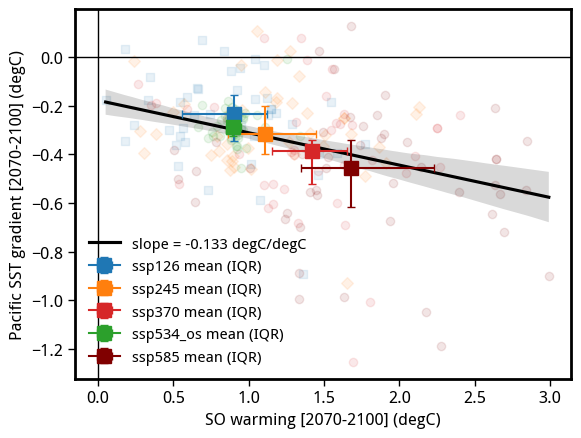

In [ ]:
plt.axhline(0.0, color='k', lw=1.0)
plt.axvline(0.0, color='k', lw=1.0)
plt.scatter(so_warming1, grad_weakening1, color='tab:blue', marker='s', alpha=0.1)
plt.scatter(so_warming2, grad_weakening2, color='tab:orange', marker='D', alpha=0.1)
plt.scatter(so_warming3, grad_weakening3, color='tab:red', marker='o', alpha=0.1)
plt.scatter(so_warming5o, grad_weakening5o, color='tab:green', marker='o', alpha=0.1)
plt.scatter(so_warming5, grad_weakening5, color='maroon', marker='o', alpha=0.1)
reg_res = stats.linregress(so_warming[~(np.isnan(so_warming) | np.isnan(grad_weakening))], grad_weakening[~(np.isnan(so_warming) | np.isnan(grad_weakening))])
sns.regplot(x=so_warming, y=grad_weakening, scatter=False, color='k', label = f'slope = {np.round(reg_res.slope, 3)} degC/degC')

median_x = so_warming1.quantile(0.5)
median_y = grad_weakening1.quantile(0.5)
lq_x = so_warming1.quantile(0.25)
lq_y = grad_weakening1.quantile(0.25)
uq_x = so_warming1.quantile(0.75)
uq_y = grad_weakening1.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:blue', label='ssp126 mean (IQR)')

median_x = so_warming2.quantile(0.5)
median_y = grad_weakening2.quantile(0.5)
lq_x = so_warming2.quantile(0.25)
lq_y = grad_weakening2.quantile(0.25)
uq_x = so_warming2.quantile(0.75)
uq_y = grad_weakening2.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:orange', label='ssp245 mean (IQR)')


median_x = so_warming3.quantile(0.5)
median_y = grad_weakening3.quantile(0.5)
lq_x = so_warming3.quantile(0.25)
lq_y = grad_weakening3.quantile(0.25)
uq_x = so_warming3.quantile(0.75)
uq_y = grad_weakening5.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:red', label='ssp370 mean (IQR)')


median_x = so_warming5o.quantile(0.5)
median_y = grad_weakening5o.quantile(0.5)
lq_x = so_warming5o.quantile(0.25)
lq_y = grad_weakening5o.quantile(0.25)
uq_x = so_warming5o.quantile(0.75)
uq_y = grad_weakening5o.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:green', label='ssp534_os mean (IQR)')

median_x = so_warming5.quantile(0.5)
median_y = grad_weakening5.quantile(0.5)
lq_x = so_warming5.quantile(0.25)
lq_y = grad_weakening5.quantile(0.25)
uq_x = so_warming5.quantile(0.75)
uq_y = grad_weakening5.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='maroon', label='ssp585 mean (IQR)')


plt.ylabel('Pacific SST gradient [2070-2100] (degC)')
plt.xlabel('SO warming [2070-2100] (degC)')
plt.legend(frameon=False, fontsize=11)
# plt.savefig('./images/so_warming_sst_grad_relationship.png', dpi=300, bbox_inches='tight')
stats.spearmanr(so_warming[~(np.isnan(so_warming) | np.isnan(grad_weakening))], grad_weakening[~(np.isnan(so_warming) | np.isnan(grad_weakening))])

SignificanceResult(statistic=-0.3228695813705363, pvalue=1.246300734732634e-06)

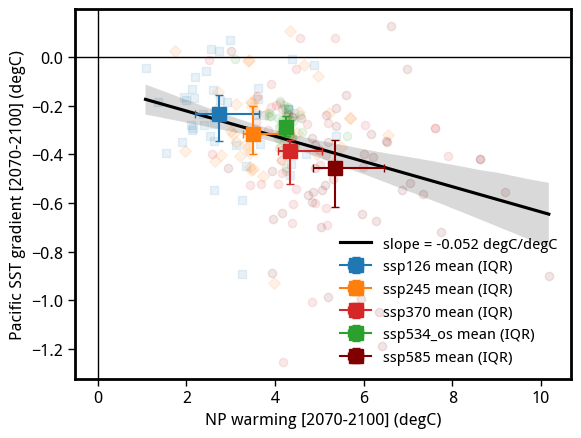

In [ ]:
plt.axhline(0.0, color='k', lw=1.0)
plt.axvline(0.0, color='k', lw=1.0)
plt.scatter(np_warming1, grad_weakening1, color='tab:blue', marker='s', alpha=0.1)
plt.scatter(np_warming2, grad_weakening2, color='tab:orange', marker='D', alpha=0.1)
plt.scatter(np_warming3, grad_weakening3, color='tab:red', marker='o', alpha=0.1)
plt.scatter(np_warming5o, grad_weakening5o, color='tab:green', marker='o', alpha=0.1)
plt.scatter(np_warming5, grad_weakening5, color='maroon', marker='o', alpha=0.1)
reg_res = stats.linregress(np_warming[~(np.isnan(np_warming) | np.isnan(grad_weakening))], grad_weakening[~(np.isnan(np_warming) | np.isnan(grad_weakening))])
sns.regplot(x=np_warming, y=grad_weakening, scatter=False, color='k', label = f'slope = {np.round(reg_res.slope, 3)} degC/degC')

median_x = np_warming1.quantile(0.5)
median_y = grad_weakening1.quantile(0.5)
lq_x = np_warming1.quantile(0.25)
lq_y = grad_weakening1.quantile(0.25)
uq_x = np_warming1.quantile(0.75)
uq_y = grad_weakening1.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:blue', label='ssp126 mean (IQR)')

median_x = np_warming2.quantile(0.5)
median_y = grad_weakening2.quantile(0.5)
lq_x = np_warming2.quantile(0.25)
lq_y = grad_weakening2.quantile(0.25)
uq_x = np_warming2.quantile(0.75)
uq_y = grad_weakening2.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:orange', label='ssp245 mean (IQR)')


median_x = np_warming3.quantile(0.5)
median_y = grad_weakening3.quantile(0.5)
lq_x = np_warming3.quantile(0.25)
lq_y = grad_weakening3.quantile(0.25)
uq_x = np_warming3.quantile(0.75)
uq_y = grad_weakening5.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:red', label='ssp370 mean (IQR)')


median_x = np_warming5o.quantile(0.5)
median_y = grad_weakening5o.quantile(0.5)
lq_x = np_warming5o.quantile(0.25)
lq_y = grad_weakening5o.quantile(0.25)
uq_x = np_warming5o.quantile(0.75)
uq_y = grad_weakening5o.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='tab:green', label='ssp534_os mean (IQR)')

median_x = np_warming5.quantile(0.5)
median_y = grad_weakening5.quantile(0.5)
lq_x = np_warming5.quantile(0.25)
lq_y = grad_weakening5.quantile(0.25)
uq_x = np_warming5.quantile(0.75)
uq_y = grad_weakening5.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=3, color='maroon', label='ssp585 mean (IQR)')


plt.ylabel('Pacific SST gradient [2070-2100] (degC)')
plt.xlabel('NP warming [2070-2100] (degC)')
plt.legend(frameon=False, fontsize=11)
# plt.savefig('./images/np_warming_sst_grad_relationship.png', dpi=300, bbox_inches='tight')
stats.spearmanr(np_warming[~(np.isnan(np_warming) | np.isnan(grad_weakening))], grad_weakening[~(np.isnan(np_warming) | np.isnan(grad_weakening))])